<a href="https://colab.research.google.com/github/annna-martynova/-E-Commerce-Sales-Analytics/blob/main/E_Commerce_Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This file presents a comprehensive analysis of an online furniture store's sales performance across November 2020 – January 2021.

**Data & Tools:** Raw data was extracted from Google BigQuery using SQL, processed and analyzed in Python (Pandas, SciPy, Matplotlib etc.), and visualized in Tableau Public.

**The analysis covers:**

- Sales performance by geography (continents & countries)
- Traffic source & channel effectiveness
- Device & browser behavior
- Product category trends
- Registered vs. unregistered user behavior
- Statistical testing of group differences (Mann-Whitney, Kruskal-Wallis, Z-test)

Dashboard link: https://public.tableau.com/app/profile/anna.martynova/viz/E-CommerceSales_17797349252600/E-CommerceSales#1

In [ ]:
#installing and updating the Google Cloud BigQuery client library
!pip install --upgrade google-cloud-bigquery

In [ ]:
#installing all necessary libraries
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.cloud.bigquery.job import query
#authenticating
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

query = """
SELECT
s.date as order_date,
s.ga_session_id,
sp.continent,
sp.country,
sp.device,
sp.browser,
sp.operating_system,
sp.mobile_model_name,
sp.language as browser_language,
sp.channel as traffic_channel,
sp.name as traffic_source,
acs.account_id,
 CASE WHEN ac.is_verified = 1 THEN "True"
      WHEN ac.is_verified = 0 THEN "False"
      END as is_verified,
 CASE WHEN ac.is_unsubscribed = 0 THEN "True"
      WHEN ac.is_unsubscribed = 1 THEN "False"
      END as is_subscribed,
  p.category as product_category,
  p.name as product_name,
  p.price,
  p.short_description
FROM data-analytics-mate.DA.session as s
LEFT JOIN data-analytics-mate.DA.session_params as sp
ON s.ga_session_id = sp.ga_session_id
LEFT JOIN data-analytics-mate.DA.account_session as acs
ON s.ga_session_id = acs.ga_session_id
LEFT JOIN data-analytics-mate.DA.account as ac
ON acs.account_id = ac.id
LEFT JOIN data-analytics-mate.DA.order as o
ON o.ga_session_id = s.ga_session_id
LEFT JOIN data-analytics-mate.DA.product as p
ON o.item_id = p.item_id
"""

query_job = client.query(query).result()
session_info = query_job.to_dataframe()
session_info.head()


,order_date,ga_session_id,continent,country,device,browser,operating_system,mobile_model_name,browser_language,traffic_channel,traffic_source,account_id,is_verified,is_subscribed,product_category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Macintosh,Safari,zh,Paid Search,<Other>,<NA>,None,None,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Web,Chrome,en-us,Organic Search,(organic),<NA>,None,None,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,Web,<Other>,zh,Direct,(direct),<NA>,None,None,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,Android,<Other>,es-es,Direct,(direct),<NA>,None,None,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Windows,Chrome,en-us,Direct,(direct),<NA>,None,None,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
session_info['order_date'] = pd.to_datetime(session_info['order_date'])
session_info['year_month'] = session_info['order_date'].dt.to_period('M').astype(str)
session_info['is_registered'] = session_info['account_id'].notna()

In [ ]:
session_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   order_date         349545 non-null  datetime64[ns]
 1   ga_session_id      349545 non-null  Int64         
 2   continent          349545 non-null  object        
 3   country            349545 non-null  object        
 4   device             349545 non-null  object        
 5   browser            349545 non-null  object        
 6   operating_system   349545 non-null  object        
 7   mobile_model_name  349545 non-null  object        
 8   browser_language   235279 non-null  object        
 9   traffic_channel    349545 non-null  object        
 10  traffic_source     349545 non-null  object        
 11  account_id         27945 non-null   Int64         
 12  is_verified        27945 non-null   object        
 13  is_subscribed      27945 non-null   object  

In [ ]:
print(f"Total count of unique sessions: {session_info['ga_session_id'].nunique()}")

Total count of unique sessions: 349545


In [ ]:
print(f"Data evaluation period from {session_info['order_date'].min()} to {session_info['order_date'].max()}")

Data evaluation period from 2020-11-01 00:00:00 to 2021-01-31 00:00:00


In [ ]:
print(f"Percent of missing values by columns")
session_info.isnull().sum() / len(session_info) * 100

Percent of missing values by columns


,0
order_date,0.000000
ga_session_id,0.000000
continent,0.000000
country,0.000000
device,0.000000
browser,0.000000
operating_system,0.000000
mobile_model_name,0.000000
browser_language,32.689925
traffic_channel,0.000000


The largest number of missing values ​​is in the account_id, is_verified, is_subscribed columns. This is due to the fact that most sessions took place in guest mode without logging into a personal account.

In [ ]:
for col in ['continent', 'device', 'traffic_channel', 'traffic_source']:
    top = session_info[col].value_counts().index[0]
    pct = session_info[col].value_counts(normalize=True).iloc[0] * 100
    print(f"Most common {col}: {top} ({pct:.1f}%)")

Most common continent: Americas (55.3%)
Most common device: desktop (58.5%)
Most common traffic_channel: Organic Search (35.6%)
Most common traffic_source: (organic) (34.1%)


In [ ]:
top_3_continents_by_sales = session_info.groupby('continent').agg(
    {'product_name':'count', 'price':'sum'}).rename(
        columns={
    'product_name': 'total_orders',
    'price': 'total_revenue'
    }).sort_values(
    by="total_orders", ascending = False)
top_3_continents_by_sales = top_3_continents_by_sales.head(3).reset_index()
top_3_continents_by_sales

,continent,total_orders,total_revenue
0,Americas,18553,17665280.0
1,Asia,7950,7601298.3
2,Europe,6261,5934624.2


Americas is the most popular region both by sales and revenue

In [ ]:
top_5_countries_by_sales = session_info.groupby('country').agg(
    {'product_name':'count', 'price':'sum'}).rename(
        columns={
    'product_name': 'total_orders',
    'price': 'total_revenue'
    }).sort_values(
    by="total_orders", ascending = False).reset_index()
top_5_countries_by_sales = top_5_countries_by_sales.head()
top_5_countries_by_sales

,country,total_orders,total_revenue
0,United States,14673,13943553.9
1,India,3029,2809762.0
2,Canada,2560,2437921.0
3,United Kingdom,1029,938317.9
4,France,678,710692.8


In [ ]:
top_10_categories = pd.pivot_table(session_info, index='product_category', values='price', aggfunc='sum').reset_index()
top_10_categories.columns = ['product_category', 'total_revenue']
top_10_categories = top_10_categories.sort_values(by='total_revenue', ascending=False).head(10)
top_10_categories

,product_category,total_revenue
12,Sofas & armchairs,8388254.5
5,Chairs,6147748.8
1,Beds,4919725.0
2,Bookcases & shelving units,3640818.1
3,Cabinets & cupboards,2336499.5
9,Outdoor furniture,2142222.2
13,Tables & desks,1790307.5
6,Chests of drawers & drawer units,906562.5
0,Bar furniture,735503.0
7,Children's furniture,467697.0


In [ ]:
top_10_categories_USA = pd.pivot_table(session_info[session_info['country'] == "United States"], index='product_category', values='price', aggfunc='sum').reset_index()
top_10_categories_USA.columns = ['product_category', 'total_revenue']
top_10_categories_USA = top_10_categories_USA.sort_values(by='total_revenue', ascending=False).head(10)
top_10_categories_USA

,product_category,total_revenue
12,Sofas & armchairs,3707144.5
5,Chairs,2619773.8
1,Beds,2213058.0
2,Bookcases & shelving units,1567606.9
3,Cabinets & cupboards,994545.5
9,Outdoor furniture,929245.2
13,Tables & desks,777865.0
6,Chests of drawers & drawer units,382388.0
0,Bar furniture,330805.0
7,Children's furniture,207575.0


After analyzing the top 10 categories overall and the top 10 in the US. It can be concluded that all categories and their order are absolutely identical. Also, it is noticeable that the total income from the US is almost half of the total income in each category

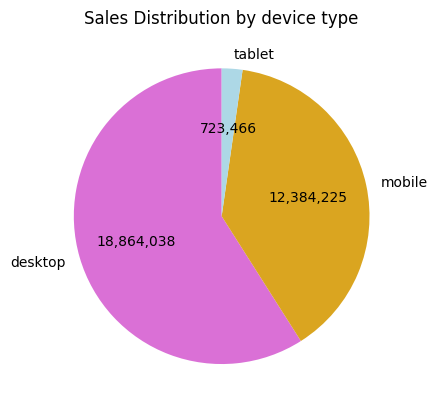

In [ ]:
#sales analysis by device type
sales_by_device_type = session_info.groupby('device').agg(revenue=('price', 'sum')).rename(columns = {'price':'revenue'}).sort_values(by='revenue', ascending = False).reset_index()
total = sales_by_device_type['revenue'].sum()
plt.pie(sales_by_device_type['revenue'], labels=sales_by_device_type['device'],
                                                autopct=lambda p: f'{int(p * total / 100):,}',
                                                colors=['orchid', 'goldenrod', 'lightblue'],
                                                startangle=90)
plt.title("Sales Distribution by device type")
plt.show()

The main sales are made through the desktop version of the site. This is due to the specificity of the product, as the most popular types of categories are furniture, which usually takes more time to choose a product.

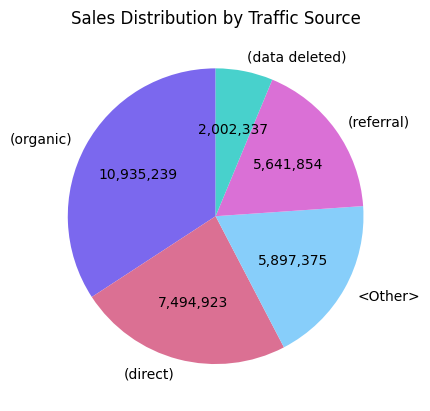

In [ ]:
#sales analysis by traffic source

sales_by_traffic = session_info.groupby('traffic_source').agg(revenue=('price', 'sum')).rename(columns = {'price':'revenue'}).sort_values(by='revenue', ascending = False).reset_index()
total = sales_by_traffic['revenue'].sum()
plt.pie(sales_by_traffic['revenue'], labels= sales_by_traffic['traffic_source'],
                                             autopct=lambda p: f'{int(p * total / 100):,}',
                                            colors=['mediumslateblue', 'palevioletred', 'lightskyblue', 'orchid', 'mediumturquoise'],
                                            startangle=90)
plt.title('Sales Distribution by Traffic Source')
plt.show()

The most popular source of customer traffic is organic search. The largest percentage of visitors to a site comes from there.

In [ ]:
percent_of_verified_clients = round(np.count_nonzero(session_info['is_verified'])/np.count_nonzero(session_info['account_id']) * 100, 2)
print(f'The percentage of verified users out of registered users is {percent_of_verified_clients}%')

The percentage of verified users out of registered users is 7.99%


In [ ]:
percent_of_unsubscribed_clients = round(session_info[session_info['is_subscribed'] == "False"].shape[0]/np.count_nonzero(session_info['account_id']) * 100, 2)
print(f"Percent of registered but unsubscribed clients is {percent_of_unsubscribed_clients}%")

Percent of registered but unsubscribed clients is 1.35%


In [ ]:
subscribed_status = session_info.dropna(subset = 'is_subscribed')

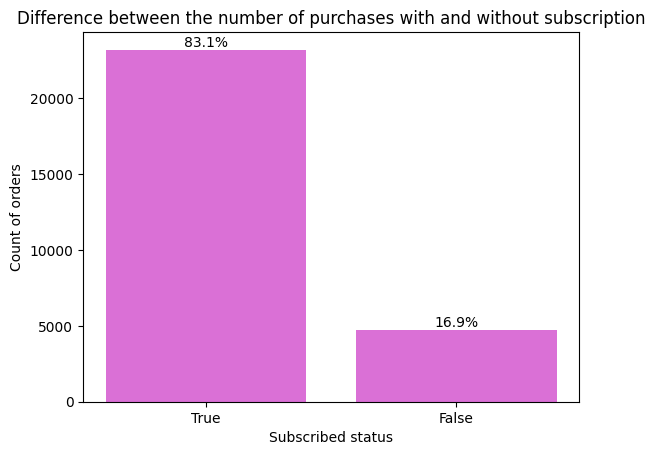

In [ ]:
counts = subscribed_status.groupby('is_subscribed').size().sort_values(ascending=False)
bars = plt.bar(counts.index, counts.values, color='orchid')

total = counts.sum()
percentages = (counts.values / total * 100).round(1)
labels = [f'{p}%' for p in percentages]

plt.title('Difference between the number of purchases with and without subscription')
plt.ylabel('Count of orders')
plt.xlabel('Subscribed status')
plt.bar_label(bars, labels=labels)
plt.show()

The analysis shows that users with subscriptions place significantly more orders compared to non-subscribed users. Specifically, the number of orders generated by subscribed users is approximately five times higher, indicating a strong correlation between subscription status and user purchasing activity.


In [ ]:
registration_by_countries = subscribed_status.groupby('country').agg(count_of_registered_users =('is_verified','count')).sort_values(by= 'count_of_registered_users', ascending=False)
registration_by_countries.head(10)

,count_of_registered_users
country,
United States,12384
India,2687
Canada,2067
United Kingdom,859
France,553
Spain,536
Taiwan,500
China,490
Germany,490


The analysis indicates that the USA has a significantly higher number of registered users compared to other countries, making it the most dominant market within the dataset.


In [ ]:
session_info['has_order'] = session_info['price'].notna()

In [ ]:
conversion_by_traffic_sourse = session_info.groupby('traffic_source').agg(session_with_orders = ('has_order',  'sum'), total_session = ('ga_session_id', 'count'))
conversion_by_traffic_sourse['conversion_rate'] = conversion_by_traffic_sourse['session_with_orders']/conversion_by_traffic_sourse['total_session'] * 100
conversion_by_traffic_sourse.sort_values(by='conversion_rate', ascending=False)

,session_with_orders,total_session,conversion_rate
traffic_source,,,
(referral),6001,61436,9.767889
(organic),11430,119024,9.603105
(data deleted),2055,21414,9.596526
(direct),7800,81382,9.584429
<Other>,6252,66289,9.431429


Sales conversion rates remain relatively consistent across all traffic sources, with only minor differences observed between the highest and lowest-performing channels

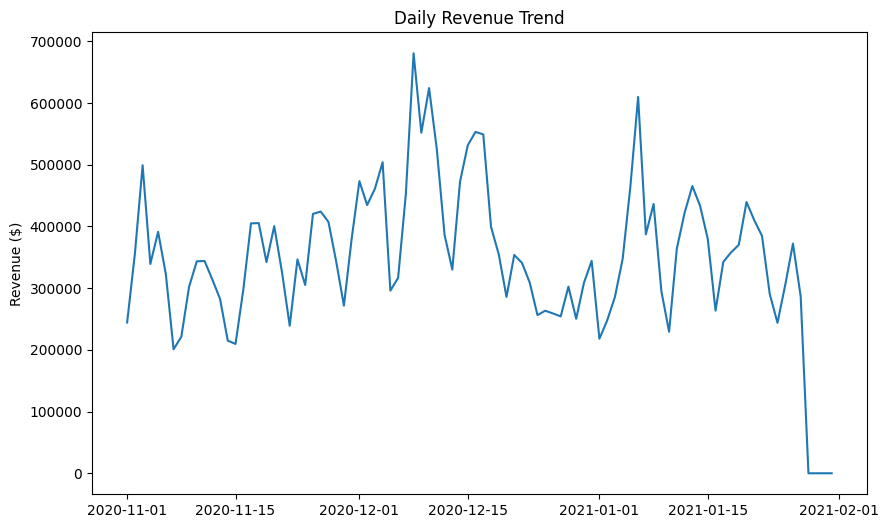

In [ ]:
sales_by_date = session_info.groupby('order_date').agg(revenue = ('price', 'sum')).reset_index().sort_values(by='order_date', ascending=True)
plt.figure(figsize=(10, 6))
plt.plot(sales_by_date['order_date'], sales_by_date['revenue'])
plt.title("Daily Revenue Trend")
plt.ylabel("Revenue ($)")
plt.show()

The analysis shows weekly changes in income, with the highest revenue on Tuesday and the lowest on Saturday. There are also two noticeable peaks on December 8 and January 6. However, between these dates, income drops significantly, which is unusual for the Christmas holiday period, when sales are usually higher.

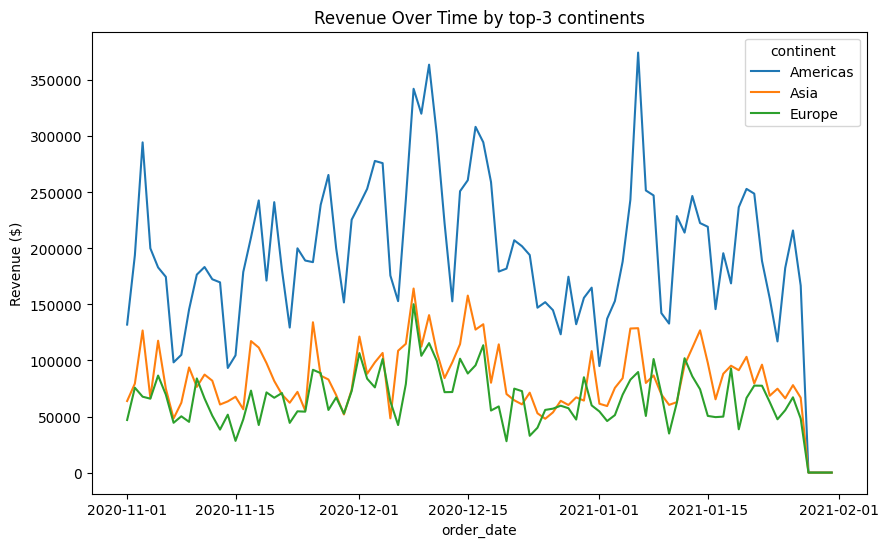

In [ ]:
sales_by_date_and_continents = session_info.groupby(['order_date', 'continent']).agg(revenue = ('price', 'sum')).reset_index().sort_values(by='order_date', ascending=True)
sales_by_date_and_continents = sales_by_date_and_continents[sales_by_date_and_continents['continent'].isin(['Americas', 'Asia', 'Europe'])]
plt.figure(figsize=(10, 6))
sns.lineplot(data=sales_by_date_and_continents, x='order_date', y='revenue', hue='continent')
plt.title('Revenue Over Time by top-3 continents')
plt.ylabel('Revenue ($)')
plt.show()

The same patterns are observed across top-3 continents. There is a clear weekly seasonality, along with a notable drop in sales between December 20 and January 1.


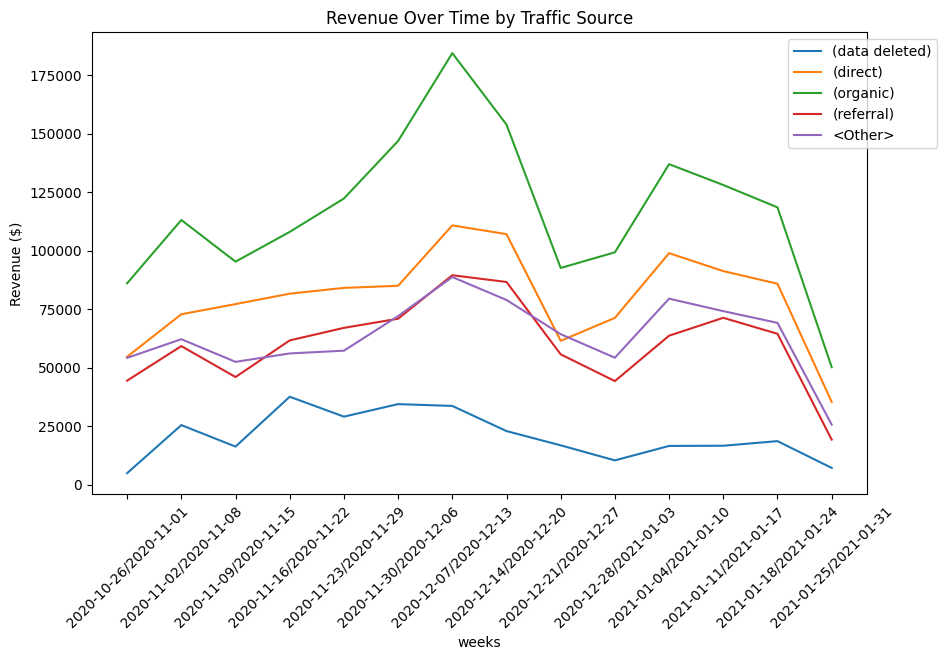

In [ ]:
sales_by_date_and_traffic = session_info.groupby(['order_date', 'traffic_source']).agg(revenue = ('price', 'sum')).reset_index().sort_values(by='order_date', ascending=True)
sales_by_date_and_traffic['order_date']= pd.to_datetime(sales_by_date_and_traffic['order_date'])
sales_by_date_and_traffic['weeks'] = sales_by_date_and_traffic['order_date'].dt.to_period('W').astype(str)
plt.figure(figsize=(10, 6))
sns.lineplot(data=sales_by_date_and_traffic, x='weeks', y='revenue', hue='traffic_source', errorbar=None)
plt.title('Revenue Over Time by Traffic Source')
plt.ylabel('Revenue ($)')
plt.legend(bbox_to_anchor=(1.1, 1))
plt.xticks(rotation=45)
plt.show()

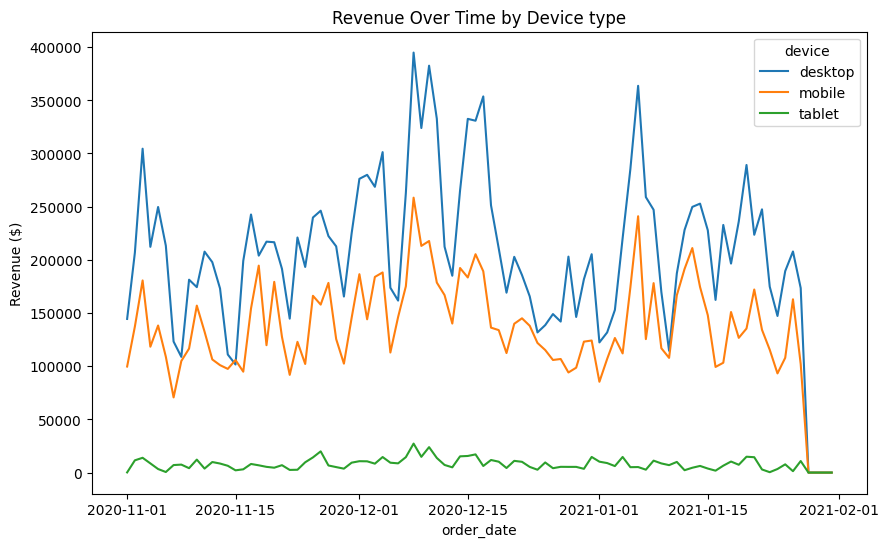

In [ ]:
sales_by_date_and_device = session_info.groupby(['order_date', 'device']).agg(revenue = ('price', 'sum')).reset_index().sort_values(by='order_date', ascending=True)
plt.figure(figsize=(10, 6))
sns.lineplot(data=sales_by_date_and_device, x='order_date', y='revenue', hue='device')
plt.title('Revenue Over Time by Device type')
plt.ylabel('Revenue ($)')
plt.show()

Overall sales dynamics and segmented metrics follow the same trends, with no sales recorded from January 29 to January 31. Across all segments and overall indicators, there is clear weekly seasonality, as well as a decline in activity between December 20 and January 1.

In terms of performance, Americas generate the highest revenue by continent, Organic is the leading traffic source, and desktop is the dominant device category.


In [ ]:
device_and_traffic_session_cnt = session_info.pivot_table(values='ga_session_id',
                                                          index='traffic_channel',
                                                          columns='device',
                                                          aggfunc='count',
                                                          margins=True,
                                                          margins_name='Grand Total')
device_and_traffic_session_cnt

device,desktop,mobile,tablet,Grand Total
traffic_channel,,,,
Direct,47825,31745,1812,81382
Organic Search,72622,49014,2789,124425
Paid Search,55167,37034,2140,94341
Social Search,16288,10988,638,27914
Undefined,12527,8486,470,21483
Grand Total,204429,137267,7849,349545


The table shows that Organic Search is the most popular traffic channel, while Desktop is the most commonly used device type among users.


In [ ]:
sales_df = session_info[session_info['country'].isin(top_5_countries_by_sales['country']) & session_info['product_category'].isin(top_10_categories['product_category'])]
sales_by_countries_and_categories = sales_df.pivot_table(values='price',
                                                         index='product_category',
                                                         columns= 'country',
                                                         aggfunc= 'sum')
sales_by_countries_and_categories['Total'] = sales_by_countries_and_categories.sum(axis=1)
sales_by_countries_and_categories = sales_by_countries_and_categories.sort_values('Total', ascending=False)
sales_by_countries_and_categories

country,Canada,France,India,United Kingdom,United States,Total
product_category,,,,,,
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5,5610549.0
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8,3904372.6
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0,3176379.5
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9,2398913.8
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5,1499021.5
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2,1374346.2
Tables & desks,132678.0,42299.0,186157.5,49374.0,777865.0,1188373.5
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0,585779.5
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0,473488.0


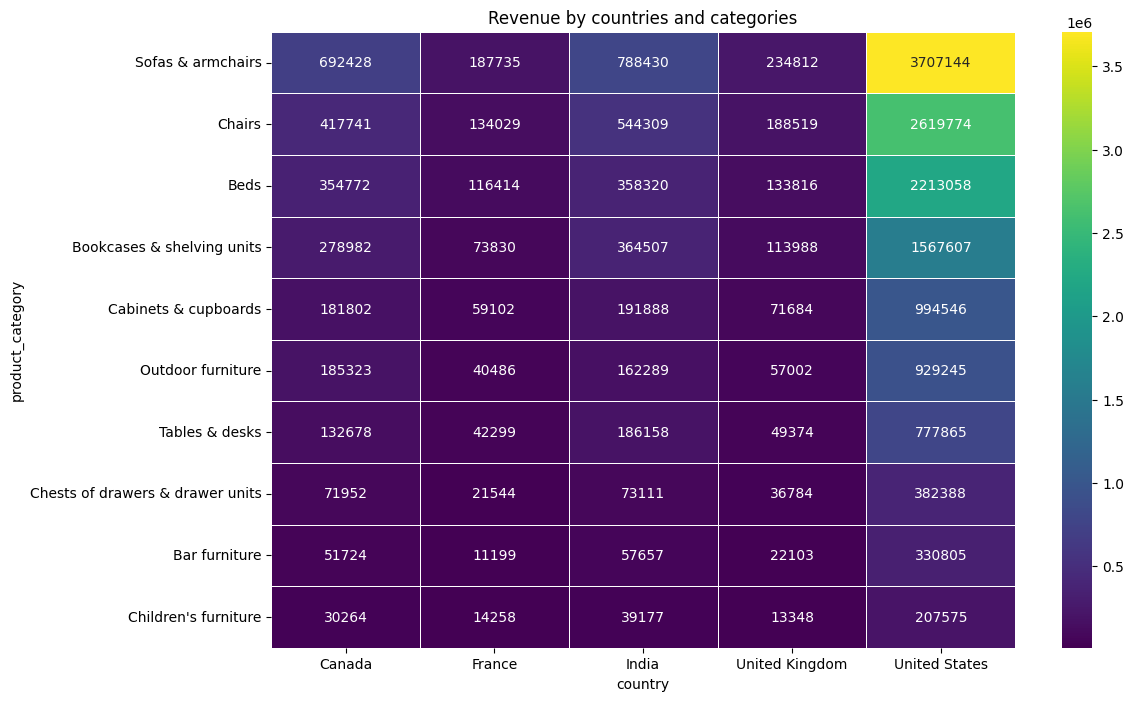

In [ ]:
sales_by_countries_and_categories_heatmap = sales_by_countries_and_categories.drop(columns='Total')
plt.figure(figsize=(12, 8))

sns.heatmap(sales_by_countries_and_categories_heatmap,
            annot=True,
            fmt='.0f',
            cmap='viridis',
            linewidths=0.5,
            linecolor='white',
            cbar=True)
plt.title('Revenue by countries and categories')
plt.show()

The analysis confirms that the USA is the leading country in terms of revenue, generating nearly half of the total revenue across each category. Additionally, among the top 5 countries, Sofas & Armchairs is the most profitable product category.


In [ ]:
sessions_by_days = session_info.groupby(by='order_date').agg(session_cnt = ('ga_session_id', 'count'), daily_revenue = ('price', 'sum'))
sessions_by_days.head()

,session_cnt,daily_revenue
order_date,,
2020-11-01,2576,244292.5
2020-11-02,3599,355506.8
2020-11-03,5173,498979.6
2020-11-04,4184,339187.1
2020-11-05,3743,391276.6


In [ ]:
#normality test
from scipy.stats import shapiro

stat, p_value = shapiro(sessions_by_days['session_cnt'])
print(f'session count: p-value = {p_value}')

stats, p_value = shapiro(sessions_by_days['daily_revenue'])
print(f'daily revenu: p-value = {p_value}')

session count: p-value = 0.026201156314308208
daily revenu: p-value = 0.0017206798751357067


In [ ]:
#calculation of the correlation coefficient
from scipy.stats import spearmanr
corr, p_value = spearmanr(sessions_by_days['session_cnt'], sessions_by_days['daily_revenue'])
print(f"Spearman correlation test:\nr = {corr}\np-value = {p_value}")

Spearman correlation test:
r = 0.8653062174563682
p-value = 9.755923586156614e-29


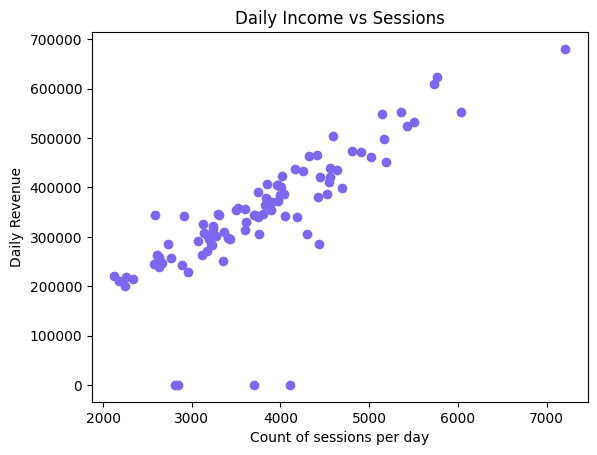

In [ ]:
plt.scatter(sessions_by_days['session_cnt'],
            sessions_by_days['daily_revenue'],
            color='mediumslateblue',
            marker='o')
plt.title('Daily Income vs Sessions')
plt.xlabel('Count of sessions per day')
plt.ylabel('Daily Revenue')
plt.show()

The correlation coefficient indicates a strong positive relationship between the number of sessions and daily revenue, while the p-value confirms that this relationship is statistically significant.

The distribution graph also reveals several outliers with zero revenue despite normal traffic levels. These cases require further analysis to identify possible reasons for the absence of revenue.

In [ ]:
#calculation of sales correlation between the top 3 continents
top_3_continents = session_info[session_info['continent'].isin(top_3_continents_by_sales['continent'])]
top_3_continents_with_revenue = top_3_continents.pivot_table( values='price',
                                                              index='order_date',
                                                              columns='continent',
                                                              aggfunc='sum')
top_3_continents_correlation_matrix = top_3_continents_with_revenue.corr(method='spearman')
top_3_continents_correlation_matrix

continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.709902,0.67257
Asia,0.709902,1.000000,0.65711
Europe,0.672570,0.657110,1.00000


In [ ]:
corr_am_asia, p_value = spearmanr(top_3_continents_with_revenue['Americas'], top_3_continents_with_revenue['Asia'])
print(f"Americas vs Asia: p-value = {p_value}")

corr_am_eu, p_value = spearmanr(top_3_continents_with_revenue['Americas'], top_3_continents_with_revenue['Europe'])
print(f"Americas vs Europe: p-value = {p_value}")

corr_asia_eu, p_value = spearmanr(top_3_continents_with_revenue['Asia'], top_3_continents_with_revenue['Europe'])
print(f"Asia vs Europe: p-value = {p_value}")

Americas vs Asia: p-value = 2.3233796296203977e-15
Americas vs Europe: p-value = 2.1035588726455927e-13
Asia vs Europe: p-value = 1.1290947217450973e-12


The correlation between revenues across all three continents is statistically significant. The Americas and Asia show a strong positive correlation (0.71). Europe demonstrates a moderate positive correlation with both the Americas (0.67) and Asia (0.63).

Overall, this suggests that sales trends across all continents move in a similar direction.


In [ ]:
#calculation of sales correlation between all traffic channels
traffic_with_revenue = session_info.pivot_table(values='price',
                                                index='order_date',
                                                columns='traffic_channel',
                                                aggfunc='sum')
traffic_with_revenue_correlation_matrix = traffic_with_revenue.corr(method='spearman')
traffic_with_revenue_correlation_matrix

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
traffic_channel,,,,,
Direct,1.000000,0.779663,0.729369,0.469342,0.556922
Organic Search,0.779663,1.000000,0.793381,0.461543,0.524677
Paid Search,0.729369,0.793381,1.000000,0.492725,0.556491
Social Search,0.469342,0.461543,0.492725,1.000000,0.462530
Undefined,0.556922,0.524677,0.556491,0.462530,1.000000


In [ ]:
from itertools import combinations

channels = traffic_with_revenue.columns.tolist()

for channel1, channel2 in combinations(channels, 2):
  corr, p_value = spearmanr(traffic_with_revenue[channel1], traffic_with_revenue[channel2])
  print(f"{channel1} vs {channel2}: p-value = {p_value}")

Direct vs Organic Search: p-value = 5.405253983075643e-20
Direct vs Paid Search: p-value = 1.65402161751709e-16
Direct vs Social Search: p-value = 2.365556386712662e-06
Direct vs Undefined: p-value = 8.156166744014837e-09
Organic Search vs Paid Search: p-value = 4.16183654939949e-21
Organic Search vs Social Search: p-value = 3.6452140656893687e-06
Organic Search vs Undefined: p-value = 7.935217742014988e-08
Paid Search vs Social Search: p-value = 6.0588880791877e-07
Paid Search vs Undefined: p-value = 8.421902659761475e-09
Social Search vs Undefined: p-value = 3.4532287442619033e-06


All traffic channels show statistically significant correlations with each other. Direct, Organic Search, and Paid Search demonstrate strong positive correlations, indicating that their performance trends move closely together. Social Search and Undefined show moderate positive correlations with other channels, suggesting a less synchronized pattern compared to the main traffic sources. These differences may require further investigation to understand the underlying drivers of their behavior.

In [ ]:
#calculation of sales correlation between the top 5 categories
top_5_categories = top_10_categories.head()
top_5_categories = session_info[session_info['product_category'].isin(top_5_categories['product_category'])]
top_5_categories_with_revenue = top_5_categories.pivot_table(values='price',
                                                             index='order_date',
                                                             columns='product_category',
                                                             aggfunc='sum')
top_5_categories_with_revenue_corr_matrix = top_5_categories_with_revenue.corr(method='spearman')
top_5_categories_with_revenue_corr_matrix

product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
product_category,,,,,
Beds,1.000000,0.542742,0.440368,0.534941,0.521715
Bookcases & shelving units,0.542742,1.000000,0.528706,0.636751,0.625603
Cabinets & cupboards,0.440368,0.528706,1.000000,0.526822,0.631204
Chairs,0.534941,0.636751,0.526822,1.000000,0.583319
Sofas & armchairs,0.521715,0.625603,0.631204,0.583319,1.000000


In [ ]:
categories = top_10_categories['product_category'].head().tolist()

for cat1, cat2 in combinations(categories, 2):
  corr, p_value = spearmanr(top_5_categories_with_revenue[cat1], top_5_categories_with_revenue[cat2])
  print(f"{cat1} vs {cat2}: p-value = {p_value}")

Sofas & armchairs vs Chairs: p-value = 2.4628200563808208e-09
Sofas & armchairs vs Beds: p-value = 1.864367723360297e-07
Sofas & armchairs vs Bookcases & shelving units: p-value = 7.188990897333014e-11
Sofas & armchairs vs Cabinets & cupboards: p-value = 4.322908272307604e-11
Chairs vs Beds: p-value = 7.913415552119658e-08
Chairs vs Bookcases & shelving units: p-value = 2.5854375788053062e-11
Chairs vs Cabinets & cupboards: p-value = 1.3449152556100263e-07
Beds vs Bookcases & shelving units: p-value = 4.690831718453576e-08
Beds vs Cabinets & cupboards: p-value = 1.7587830397743514e-05
Bookcases & shelving units vs Cabinets & cupboards: p-value = 1.1906129581027331e-07


All categories have a statistically significant moderate positive correlation with each other. This indicates that sales dynamics in different categories move in the same direction, but the synchronicity is incomplete - each category has its own independent influencing factors.

In [ ]:
#Sales analysis for registered and unregistered users

revenue_analysis_by_registration = session_info.pivot_table(values='price',
                                                            index='order_date',
                                                            columns='is_registered',
                                                            aggfunc='sum').rename(columns={True : 'registered', False : 'not_registered'})

#normality test
stat, p_value = shapiro(revenue_analysis_by_registration['not_registered'].dropna())
print(f'not_registered: p-value = {p_value}')

stat, p_value = shapiro(revenue_analysis_by_registration['registered'].dropna())
print(f'registered: p-value = {p_value}')

not_registered: p-value = 0.0012184604855253293
registered: p-value = 0.007295139880540744


Both samples are not normally distributed; therefore, the Mann–Whitney test will be used for the statistical analysis.

**H0:** The sales distribution of registered and unregistered users is the same.

**H1:** The sales distribution of registered and unregistered users is different.


In [ ]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(revenue_analysis_by_registration['registered'].dropna(), revenue_analysis_by_registration['not_registered'].dropna(), alternative='two-sided')

print(f"U-statistic: {stat}")
print(f"p-value: {p_value}")
print(f"Median revenue:\n{revenue_analysis_by_registration.median()}")

U-statistic: 352.0
p-value: 3.8805185465235906e-26
Median revenue:
is_registered
not_registered    315170.75
registered         28048.00
dtype: float64


Since the p-value is below 0.05, we reject H0 and conclude that the sales distribution between registered and unregistered users is statistically significantly different. Based on the median values, registered users generate higher revenue than unregistered users.


In [ ]:
#session analysis for traffic channels
traffic_with_session_cnt = session_info.pivot_table(values='ga_session_id',
                                                    index='order_date',
                                                    columns='traffic_channel',
                                                    aggfunc='count')
#normality test


for channel in channels:
  stat, p_value = shapiro(traffic_with_session_cnt[channel])
  print(f"{channel}: p-value = {p_value:.4f}")


Direct: p-value = 0.0343
Organic Search: p-value = 0.0123
Paid Search: p-value = 0.0108
Social Search: p-value = 0.1413
Undefined: p-value = 0.0546


Most traffic channels have a non-normal distribution; therefore, the Kruskal–Wallis test will be used for the statistical analysis.

**H0:** The distribution of the number of sessions is the same across all traffic channels.

**H1:** At least one traffic channel has a statistically significantly different distribution of the number of sessions.


In [ ]:
from scipy.stats import kruskal

stat, p_value = kruskal(
    traffic_with_session_cnt['Direct'],
    traffic_with_session_cnt['Organic Search'],
    traffic_with_session_cnt['Paid Search'],
    traffic_with_session_cnt['Social Search'],
    traffic_with_session_cnt['Undefined']
)
print(f"stat = {stat:.4f},\np-value = {p_value}")

stat = 368.9806,
p-value = 1.397036102599359e-78


Since the p-value is < 0.05, we reject H0 and conclude that at least one traffic channel has a statistically significant difference in the distribution of the number of sessions.

In [ ]:
#comparison of the proportion of sessions from Organic traffic between Europe and America
organic_search_in_am_eu = session_info[(session_info['traffic_channel'] == 'Organic Search') & (session_info['continent'].isin(['Americas', 'Europe']))]
organic_search = organic_search_in_am_eu.pivot_table(values='ga_session_id',
                                                     index='order_date',
                                                     columns='continent',
                                                     aggfunc='count')

total_sessions = session_info[session_info['continent'].isin(['Americas', 'Europe'])].pivot_table(
    values='ga_session_id',
    index='order_date',
    columns='continent',
    aggfunc='count'
)

**H0:** The proportion of organic traffic in Europe and America is the same.

**H1:** The proportion of organic traffic in Europe and America is different.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

organic_europe = organic_search['Europe'].sum()
organic_americas = organic_search['Americas'].sum()

total_europe = total_sessions['Europe'].sum()
total_americas = total_sessions['Americas'].sum()

stat, p_value = proportions_ztest(
    count=[organic_europe, organic_americas],
    nobs=[total_europe, total_americas]
)

print(f"stat = {stat:.4f}")
print(f"p-value = {p_value:.4f}")

stat = 0.2895
p-value = 0.7722


Since the p-value > 0.05, we fail to reject H0. There is not enough statistical evidence to conclude that the proportion of organic traffic differs between Europe and Americas.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

session_info.to_csv('/content/drive/MyDrive/session_info.csv', index=False)

Mounted at /content/drive
